In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Price Prediction dataset EDA

In [2]:
# load dataset
df = pd.read_csv(r'/kaggle/input/datasets/chillalyash/recommendation-system/price_prediction_dataset.csv')
df.head()

,issue,device,severity,urgent,brand,device_age_years,service_type,warranty_status,city_tier,technician_experience,price
0,overheating,cctv,low,no,Lenovo,1.0,home_service,in_warranty,tier1,3,614
1,software_issue,printer,high,yes,Acer,1.4,home_service,in_warranty,tier3,8,619
2,broken_screen,cctv,low,no,Apple,4.1,home_service,out_of_warranty,tier2,13,4036
3,broken_screen,desktop,low,yes,Canon,3.0,home_service,in_warranty,tier2,7,1676
4,strange_noise,cctv,medium,yes,HP,0.3,shop_visit,in_warranty,tier2,2,302


In [3]:
df.columns

Index(['issue', 'device', 'severity', 'urgent', 'brand', 'device_age_years',
       'service_type', 'warranty_status', 'city_tier', 'technician_experience',
       'price'],
      dtype='object')

In [4]:
df.shape

(2000, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   issue                  2000 non-null   object 
 1   device                 2000 non-null   object 
 2   severity               2000 non-null   object 
 3   urgent                 2000 non-null   object 
 4   brand                  2000 non-null   object 
 5   device_age_years       2000 non-null   float64
 6   service_type           2000 non-null   object 
 7   warranty_status        2000 non-null   object 
 8   city_tier              2000 non-null   object 
 9   technician_experience  2000 non-null   int64  
 10  price                  2000 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 172.0+ KB


In [6]:
df.describe()

,device_age_years,technician_experience,price
count,2000.000000,2000.000000,2000.00000
mean,4.067000,7.448500,1796.53450
std,2.308457,4.641241,2104.92467
min,0.000000,0.000000,100.00000
25%,2.100000,3.000000,475.75000
50%,4.200000,7.000000,910.00000
75%,6.000000,12.000000,2385.00000
max,8.000000,15.000000,16898.00000


In [7]:
df.isnull().sum()

issue                    0
device                   0
severity                 0
urgent                   0
brand                    0
device_age_years         0
service_type             0
warranty_status          0
city_tier                0
technician_experience    0
price                    0
dtype: int64

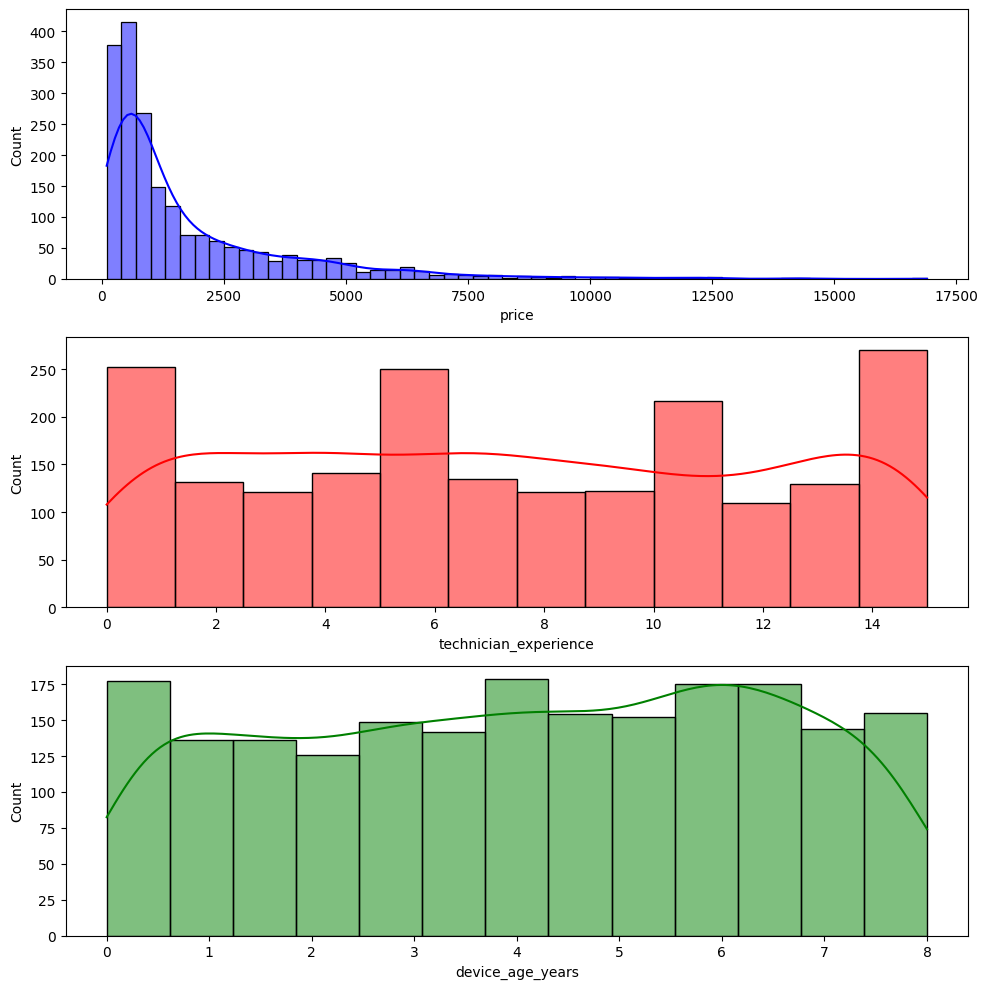

In [14]:
import random
num_cols = ['price','techician_exprience','device_age_years']
color=['red','green','blue']
fig, axes = plt.subplots(3,1, figsize=(10,10))

sns.histplot(data=df, x=df['price'], kde=True, color=random.choice(color), ax=axes[0])
sns.histplot(data=df, x=df['technician_experience'], kde=True, color=random.choice(color), ax=axes[1])
sns.histplot(data=df, x=df['device_age_years'], kde=True, color=random.choice(color), ax=axes[2])
plt.tight_layout()
plt.show()

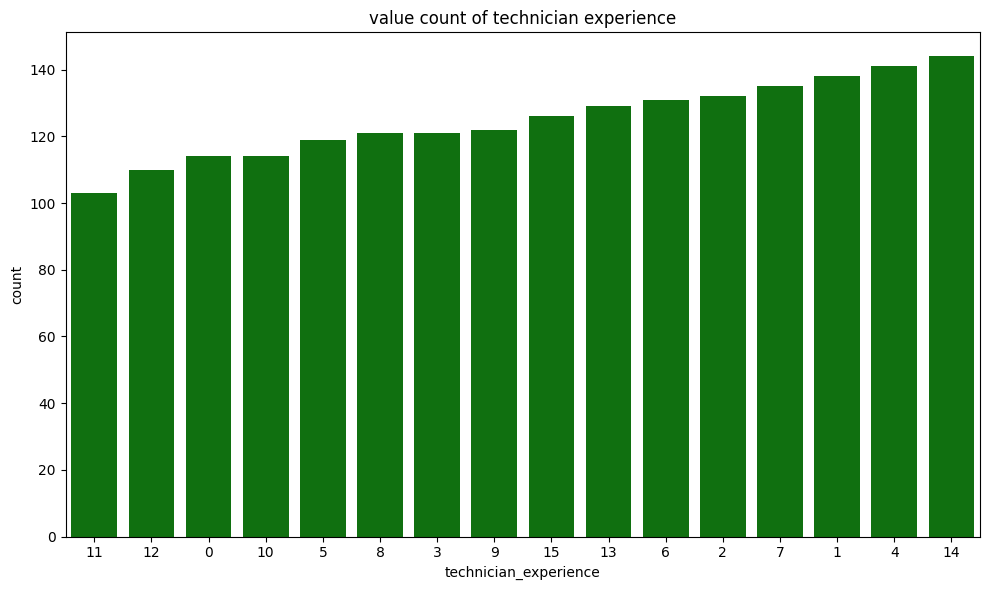

In [34]:
technician_exp = df['technician_experience'].value_counts().reset_index()
technician_exp.columns = ['technician_experience', 'count']

# Sort by count
technician_exp = technician_exp.sort_values(by='count', ascending=True)

plt.figure(figsize=(10,6))

sns.barplot(
    data=technician_exp,
    x='technician_experience',
    y='count',
    color='green',
    order=technician_exp['technician_experience']  
)
plt.title("value count of technician experience")
plt.tight_layout()
plt.show()

/tmp/ipykernel_55/333054571.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


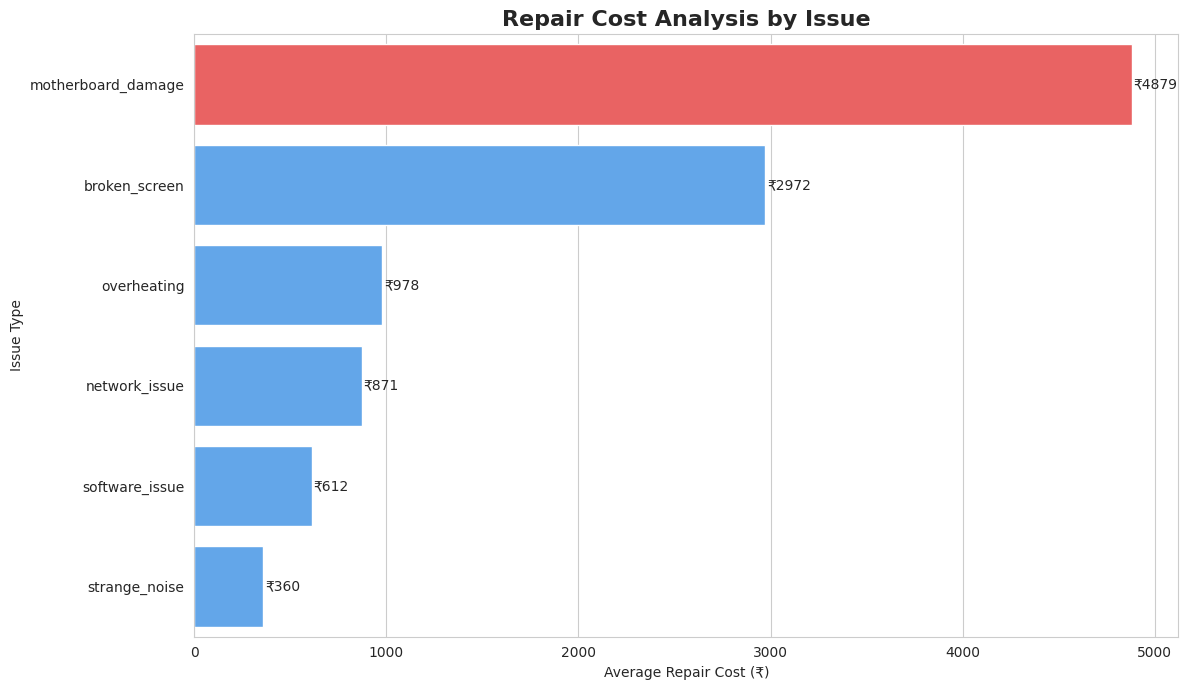

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data prep
avgPriceIssue = df.groupby('issue')['price'].mean().reset_index()
avgPriceIssue.columns = ['issue', 'avg_price']

# Sort descending
avgPriceIssue = avgPriceIssue.sort_values(by='avg_price', ascending=False)

# Style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

# Color palette (highlight top 3)
colors = ['#ff4d4d' if i < 1 else '#4da6ff' for i in range(len(avgPriceIssue))]

# Horizontal barplot (better for long labels)
barplot = sns.barplot(
    data=avgPriceIssue,
    y='issue',
    x='avg_price',
    palette=colors
)

# Add value labels
for i, value in enumerate(avgPriceIssue['avg_price']):
    plt.text(value + 10, i, f"₹{int(value)}", va='center')

# Titles & labels
plt.title("Repair Cost Analysis by Issue", fontsize=16, fontweight='bold')
plt.xlabel("Average Repair Cost (₹)")
plt.ylabel("Issue Type")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, "How Technician's experience affects price")

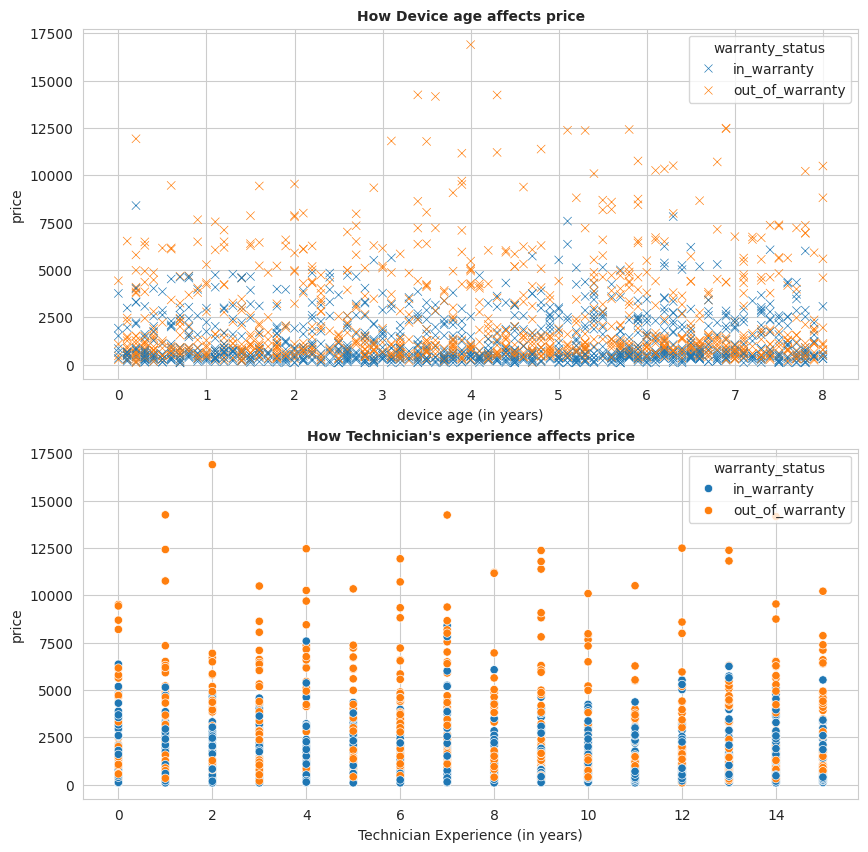

In [68]:
# scatter plot (variable relationship)
fig, axes = plt.subplots(2,1, figsize=(10,10))
sns.set_style("whitegrid")
sns.scatterplot(data=df, x=df['device_age_years'], y=df['price'], ax=axes[0], hue='warranty_status', marker='x')
axes[0].set_xlabel("device age (in years)")
axes[0].set_ylabel("price")
axes[0].set_title("How Device age affects price", fontsize=10, fontweight='bold')

sns.scatterplot(data=df, x=df['technician_experience'], y=df['price'], ax=axes[1], hue='warranty_status')
axes[1].set_xlabel("Technician Experience (in years)")
axes[1].set_ylabel("price")
axes[1].set_title("How Technician's experience affects price", fontsize=10, fontweight='bold')

# Recommend system dataset

In [2]:
df = pd.read_csv(r"/kaggle/input/datasets/chillalyash/recommendation-system/recommendation_dataset.csv")
df

,issue,device,severity,urgent,rating,num_reviews,success_rate,experience_years,distance_km,response_time_min,base_price,service_type,availability,selected
0,slow_performance,desktop,high,yes,3.5,1013,0.82,6,13.26,21,205,shop_visit,busy,1
1,overheating,router,medium,yes,3.7,1370,0.80,10,12.32,53,2625,shop_visit,available,0
2,overheating,router,high,yes,5.0,296,0.44,12,0.65,33,971,shop_visit,available,1
3,slow_performance,printer,low,yes,2.4,2358,0.66,6,10.68,114,2237,shop_visit,available,0
4,wifi_issue,laptop,low,yes,2.5,293,0.31,6,8.69,22,529,home_service,available,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,strange_noise,printer,medium,yes,4.2,728,0.54,9,14.71,6,565,home_service,available,1
2296,wifi_issue,printer,low,yes,2.2,820,0.83,10,13.89,72,860,home_service,available,1
2297,power_issue,printer,medium,no,2.9,1278,0.76,0,7.31,93,504,shop_visit,available,1
2298,strange_noise,cctv,low,no,2.4,156,0.62,13,13.07,94,925,home_service,available,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2300 entries, 0 to 2299
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   issue              2300 non-null   object 
 1   device             2300 non-null   object 
 2   severity           2300 non-null   object 
 3   urgent             2300 non-null   object 
 4   rating             2300 non-null   float64
 5   num_reviews        2300 non-null   int64  
 6   success_rate       2300 non-null   float64
 7   experience_years   2300 non-null   int64  
 8   distance_km        2300 non-null   float64
 9   response_time_min  2300 non-null   int64  
 10  base_price         2300 non-null   int64  
 11  service_type       2300 non-null   object 
 12  availability       2300 non-null   object 
 13  selected           2300 non-null   int64  
dtypes: float64(3), int64(5), object(6)
memory usage: 251.7+ KB


In [4]:
df.describe()

,rating,num_reviews,success_rate,experience_years,distance_km,response_time_min,base_price,selected
count,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000
mean,3.251565,1506.893913,0.628965,7.468696,7.605543,61.644783,1611.929130,0.522609
std,1.012472,859.175840,0.184963,4.620375,4.211027,33.623072,797.974388,0.499597
min,1.500000,11.000000,0.300000,0.000000,0.500000,5.000000,204.000000,0.000000
25%,2.400000,765.500000,0.480000,4.000000,3.887500,33.000000,922.000000,0.000000
50%,3.300000,1540.000000,0.630000,8.000000,7.500000,61.000000,1628.500000,1.000000
75%,4.100000,2223.250000,0.790000,11.000000,11.322500,91.000000,2299.000000,1.000000
max,5.000000,2997.000000,0.950000,15.000000,15.000000,120.000000,3000.000000,1.000000


In [5]:
df.isnull().sum()

issue                0
device               0
severity             0
urgent               0
rating               0
num_reviews          0
success_rate         0
experience_years     0
distance_km          0
response_time_min    0
base_price           0
service_type         0
availability         0
selected             0
dtype: int64

In [8]:
cat_cols = []
num_cols = []
for cols in df.columns:
    if df[cols].dtypes == "object":
        cat_cols.append(cols)
    else:
        num_cols.append(cols)
print("num cols = \n", num_cols)
print("total cols = ", len(num_cols))
print("cat cols =\n", cat_cols)
print("total cols =", len(cat_cols))

num cols = 
 ['rating', 'num_reviews', 'success_rate', 'experience_years', 'distance_km', 'response_time_min', 'base_price', 'selected']
total cols =  8
cat cols =
 ['issue', 'device', 'severity', 'urgent', 'service_type', 'availability']
total cols = 6


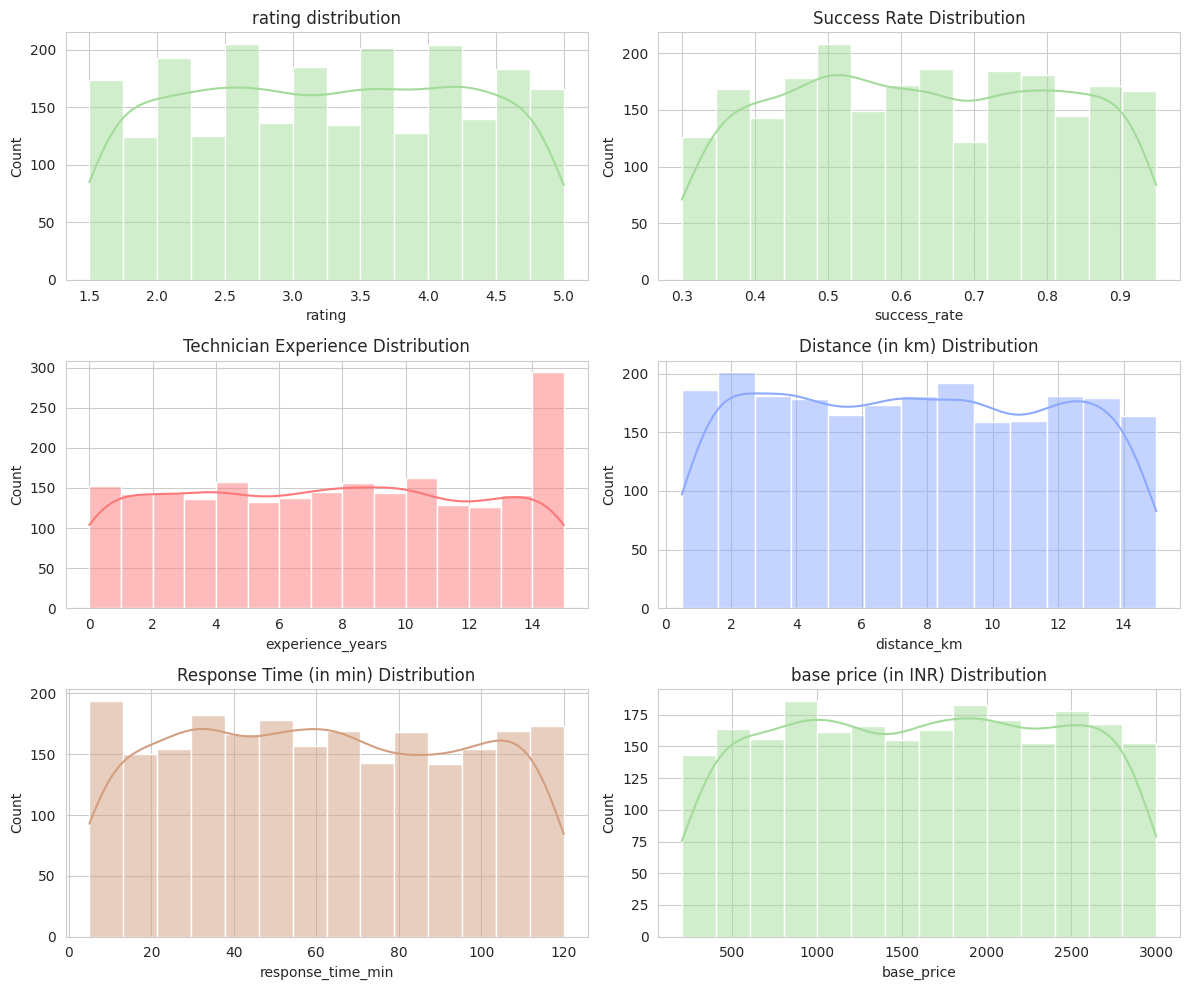

In [14]:
import random
def plot_histogram():
    random.seed(0)
    fig, axes = plt.subplots(3,2, figsize=(12,10))
    sns.set_style("whitegrid")
    
    color_lst = ['#FD7979', '#F7E396', '#8CA9FF', '#A3DC9A', '#D29F80']
    # 1st graph
    sns.histplot(data=df, x=df['rating'], ax=axes[0][0], kde=True, color=random.choice(color_lst))
    axes[0][0].set_title("rating distribution")
    # 2nd graph
    sns.histplot(data=df, x=df['success_rate'], ax=axes[0][1], kde=True, color=random.choice(color_lst))
    axes[0][1].set_title("Success Rate Distribution")
    #3rd graph
    sns.histplot(data=df, x=df['experience_years'], ax=axes[1][0],kde=True, color=random.choice(color_lst))
    axes[1][0].set_title("Technician Experience Distribution")
    #4th graph
    sns.histplot(data=df, x=df['distance_km'], ax=axes[1][1], kde=True, color=random.choice(color_lst))
    axes[1][1].set_title("Distance (in km) Distribution")
    # 5th graph
    sns.histplot(data=df, x=df['response_time_min'], ax=axes[2][0], kde=True, color=random.choice(color_lst))
    axes[2][0].set_title("Response Time (in min) Distribution")
    #6th graph
    sns.histplot(data=df, x=df['base_price'], ax=axes[2][1], kde=True, color=random.choice(color_lst))
    axes[2][1].set_title("base price (in INR) Distribution")

    plt.tight_layout()
    plt.show()


plot_histogram()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2300 entries, 0 to 2299
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   issue              2300 non-null   object 
 1   device             2300 non-null   object 
 2   severity           2300 non-null   object 
 3   urgent             2300 non-null   object 
 4   rating             2300 non-null   float64
 5   num_reviews        2300 non-null   int64  
 6   success_rate       2300 non-null   float64
 7   experience_years   2300 non-null   int64  
 8   distance_km        2300 non-null   float64
 9   response_time_min  2300 non-null   int64  
 10  base_price         2300 non-null   int64  
 11  service_type       2300 non-null   object 
 12  availability       2300 non-null   object 
 13  selected           2300 non-null   int64  
dtypes: float64(3), int64(5), object(6)
memory usage: 251.7+ KB


In [33]:
def draw_bargraph(data, label, feature):
    color_lst = ['#FD7979', '#F7E396', '#8CA9FF', '#A3DC9A', '#D29F80']
    sns.set_style("whitegrid")
    plt.figure(figsize=(8,5))
    sns.barplot(data=df, x=label, y=feature, color=random.choice(color_lst))
    plt.title(f"{label} Vs {feature}")
    plt.xlabel(f"<--------{label} -------->")
    plt.ylabel(f"<----------{feature} ----------->")
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

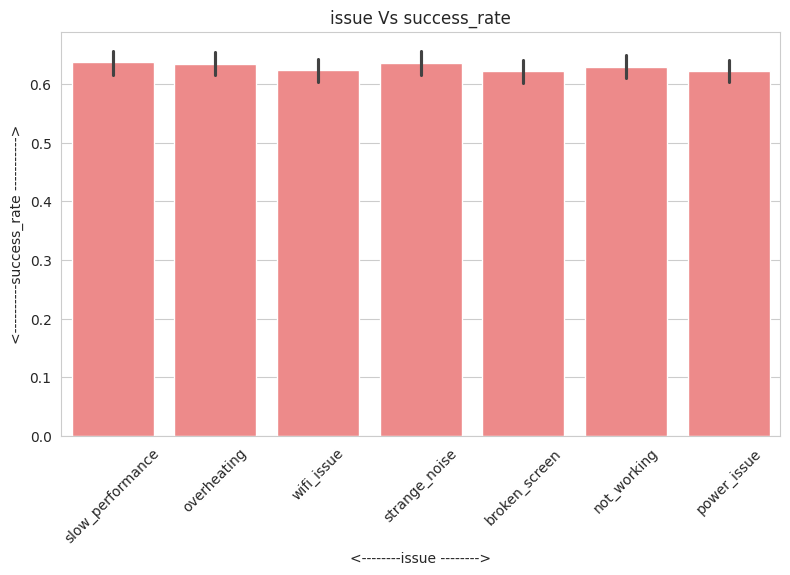

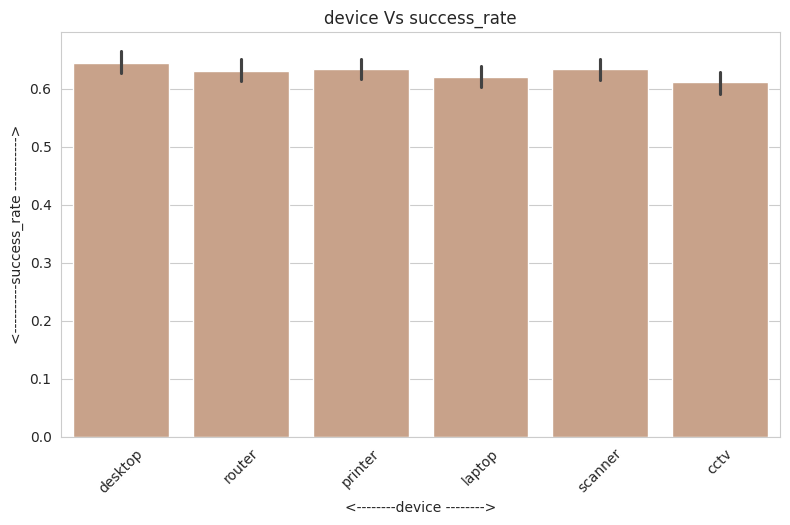

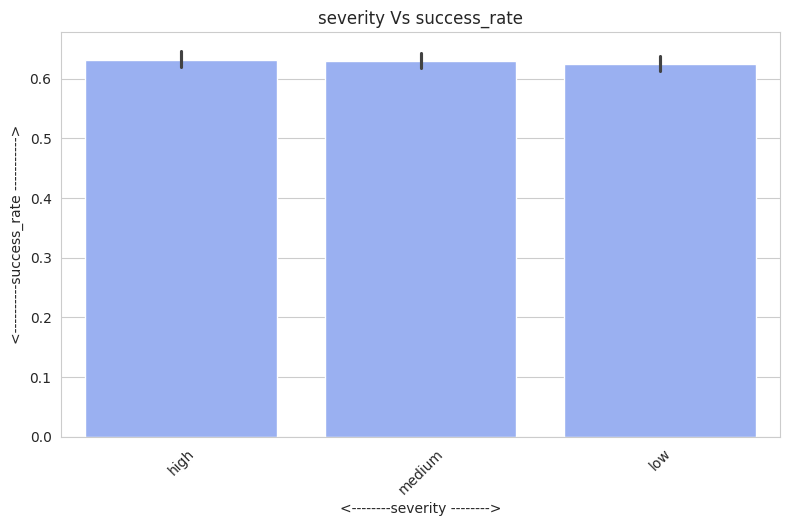

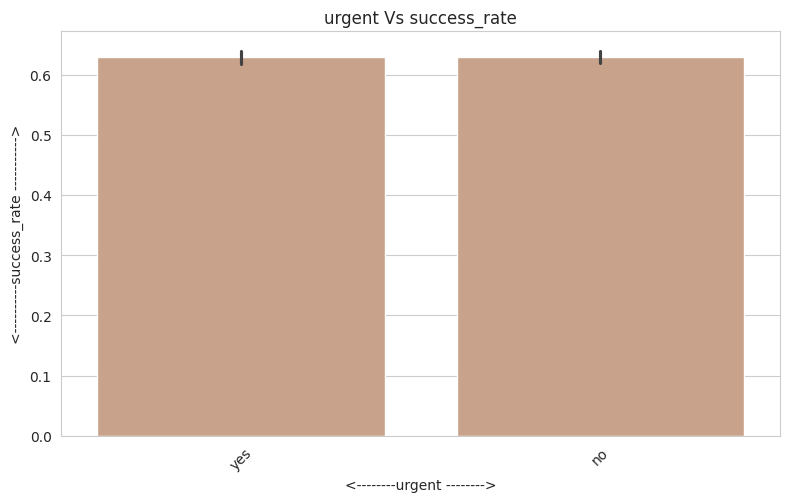

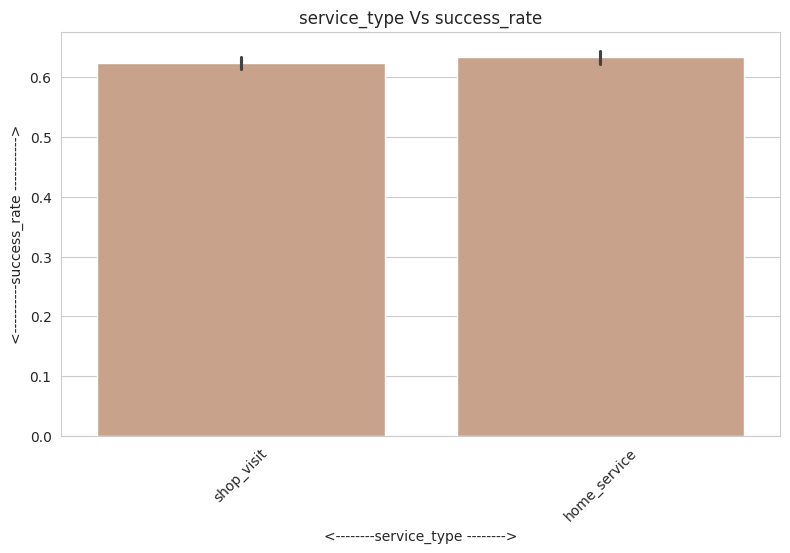

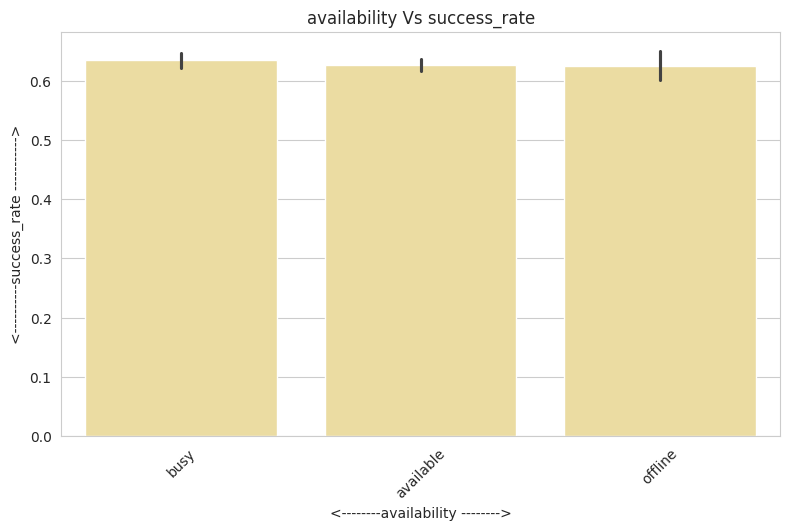

In [35]:
for cols in cat_cols:
    draw_bargraph(data=df, label=cols, feature="success_rate")